# Computer Vision Classifier Challenge

Here we are tasked with creating a Computer Vision Model that will "look" at satellite images and assess if there is a swimming pool or not in that image. This is a relatively straightforward, binary classification computer vision task.

We are given the data. Our job here is to access the data, and then to create a model that will discriminate between pool or no pool. 
The data itself will be processed in another notebook (Obtaining_data); its collection is complicated. 

Once our data are in the right format, we need to decide on a model. For tasks like this, [ResNet 50](https://www.sciencedirect.com/topics/computer-science/resnet50) is the model of choice. ResNet is a Convolutional Neural Network (CNN), which have been developed for CV tasks. It has 50 layers in the Network, hence the name ResNet50. It's been trained on 1.2M images, so a great place to start; we'll fine tune this model for our uses. Let's get started.

In [41]:
# Imports

# !pip install tensorflow
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from pathlib import Path

In [42]:
1+1 # check notebook is alive. 

2

In [43]:
# STEP 1 — Getting data in right format was a bit of a process. Let's ensure it's there:

# We need to specify our data, but from the relative root of the repo:

# Repo root = one folder up from the notebook
BASE_DIR = Path.cwd().parent 

# File path relative to repo root
data_dir = BASE_DIR / "notebooks" / "data" / "swimming_pool"

print("Looking for data in:", data_dir)
print("Exists?", os.path.exists(data_dir))

Looking for data in: /Users/gregduckworth/Git/CoCT/ds_code_challenge/notebooks/data/swimming_pool
Exists? True


In [4]:
# STEP 2 — Load dataset using TF

# load and split -- use 20% validation set. I've only saved 200 images owing to 
# reducting computational complexity, but still getting the pipeline working 
# for now.
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),  # TF will convert all images to this size -- used when training the model so need it to be 
    # in the same size when loading. 
    batch_size=32,
    label_mode='binary'
)

# validation set
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32,
    label_mode='binary'
)

# There should be 200 images, 100 in each class. 
print("Class names:", train_ds.class_names)

# Settings:
# batching based on system resources. 
AUTOTUNE = tf.data.AUTOTUNE
# cache images so faster processing. 
train_ds = train_ds.cache().shuffle(500).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 200 files belonging to 2 classes.
Using 160 files for training.
Found 200 files belonging to 2 classes.
Using 40 files for validation.
Class names: ['no', 'yes']


In [5]:
# STEP 3 — Load ResNet50 model (from TF)

# load the model (224 x 224 dimensions)
base_model = ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet", # load weights from model learned on imagenet images. 
    pooling="avg" # layer pooling strategy
)

# We don't train the base model -- freeze its weights. 
base_model.trainable = False

In [40]:
# STEP 4 — Build model architecture

model = models.Sequential([ # feed forward network 

    # randomly flip images up or down
    layers.RandomFlip("horizontal"),
    # randomly roate images by up to 10 degrees
    layers.RandomRotation(0.1),
    # randomly zoom images up to 10% 
    layers.RandomZoom(0.1),

    # Note -- we may not need the above, but it depends on the consistency of the images.
    # I haven't manually looked through all of them (in excess of 4k images), but if we 
    # expect serious variability in the way the images are captured, we will have to 
    # use something like this. 

    # use base model to input features to the input layer.
    # here, it will be 224 (pixel height) x  224 (pixel width) x 3 (RGB channels) as input layer.
    # this will convert our input images to RGB pixel values for the input layer to the NN. 
    base_model,

    # giving each input neuron a 50% chance of being set to zero, so as to avoid overtraining. 
    layers.Dropout(0.5),

    # HEAD:
    # here, we specify 128 neurons to learn from the (frozen) ResNet network. 
    layers.Dense(128, activation="relu"),
    # normalisation from the resnet to the head
    layers.BatchNormalization(),
    # setting each of the  128 neurons to 0 at 30% chance -- preventing overfitting. 
    layers.Dropout(0.3),
    # output -- sigmoid for probability
    layers.Dense(1, activation="sigmoid")
])

In [7]:
# STEP 5 — Compile model

model.compile(
    # small learning rate -- only classifier head is learning
    optimizer=tf.keras.optimizers.Adam(1e-4),
    # binary loss metric
    loss="binary_crossentropy",
    # typical ML metrics to monitor
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [8]:
# STEP 6 — Train model (classifier head)

# Only a few epochs (data runs throughs)  because I have a small sample here (200 images)
initial_epochs = 10

# preventing the optimiser from getting stuck on a plateau -- reduce learning rate if val_loss doesn't improve after 3 epochs. Safety net. 
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

# overfitting prevention:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


print("\nStarting initial training...")

# fit the model: 
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs,
    callbacks=[lr_scheduler, early_stopping]
)



Starting initial training...
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 929ms/step - accuracy: 0.5188 - auc: 0.5468 - loss: 0.9571 - precision: 0.5190 - recall: 0.5125 - val_accuracy: 0.6500 - val_auc: 0.7188 - val_loss: 0.7808 - val_precision: 0.5882 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 738ms/step - accuracy: 0.5562 - auc: 0.6415 - loss: 0.7573 - precision: 0.5517 - recall: 0.6000 - val_accuracy: 0.6500 - val_auc: 0.7475 - val_loss: 0.7583 - val_precision: 0.5882 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 737ms/step - accuracy: 0.5813 - auc: 0.6338 - loss: 0.7582 - precision: 0.5867 - recall: 0.5500 - val_accuracy: 0.6750 - val_auc: 0.7650 - val_loss: 0.7397 - val_precision: 0.6061 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 737ms/step - accuracy: 0.7000 - auc: 0.7334 - loss: 0.6779 - precision: 0.6860 - recall: 0.7375 - val_accuracy: 0.7250 - val_au

In [10]:
# STEP 7:  Save model

model_path = "pool_classifier_resnet50.h5"
model.save(model_path)

print("\nModel saved to:", model_path)



Model saved to: pool_classifier_resnet50.h5


In [13]:
# Step 8: Final Model Metrics 

results = model.evaluate(val_ds)
print(results) 


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.7500 - auc: 0.8275 - loss: 0.6677 - precision: 0.6667 - recall: 1.0000
[0.6676566004753113, 0.75, 0.8274999856948853, 0.6666666865348816, 1.0]


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step


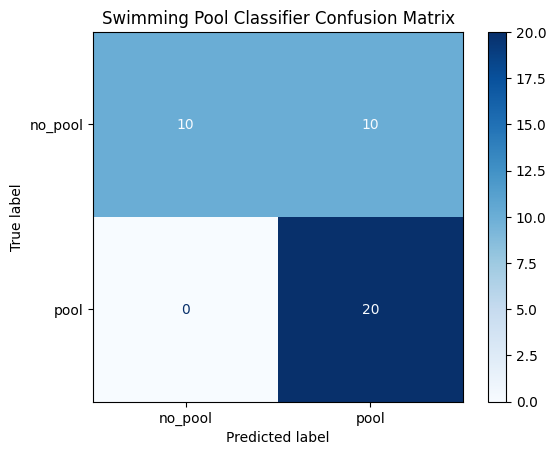

In [37]:
# Step 9: Confusion Matrix

# get validation set labels -- need to extract from all batches (batch size = 32)
val_labels = np.concatenate([y.numpy() for x, y in val_ds], axis=0).flatten()

# Predicted labels
preds  = model.predict(val_ds) 
pred_labels = (preds > 0.5).astype(int).flatten()

# Compute confusion matrix
cm = confusion_matrix(val_labels, pred_labels)

# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no_pool', 'pool'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Swimming Pool Classifier Confusion Matrix")
plt.show()



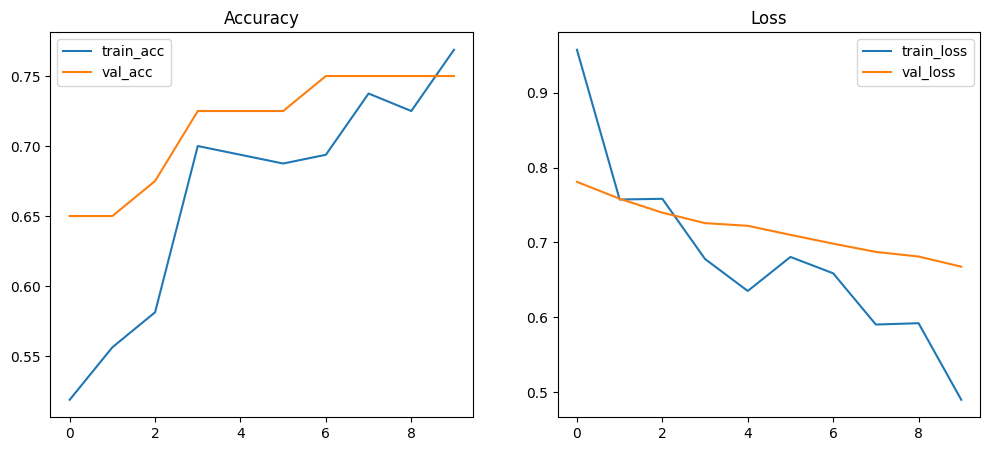

In [39]:
# Step 10: Training plots

import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Loss")
plt.legend()
plt.show()

## Analysis Report

**Model** 
This exercise uses a pretrained model, ResNet50, trained on 1.2M images. We freeze the foundation layers, and only train the classifier head. We specify a fully connected layer of 128 Neurons on top of the foundation model layers, moving to a single neuron layer with a sigmoid activation function for the probability output. Throughout the Network, we utilise Drop out layers, randomly setting some neurons in the layer to 0 to prevent over-reliance on a single feature type in the images. This is an industry standard method, and I've recently just finished using this type of model on another image classification problem.

**Performance**
The final model performs unsatisfactorily. Investigating the training logs shows that validation recall (the total number of images with a Pool that our model correctly identifies as having a Pool) is perfect upon the first epoch (val_recall = 1). This metric is consistent for all further epochs. Precision on the validation set during training (proportion of images the model predicts as having a pool that actually do have a pool) gradually increases during training. This means that our model is predicting images have pools at a much higher rate than we would like; this is a form of overfitting. We can see this in the confusion matrix -- the model perfectly predicts images with pools, but is unable to predict well images that don't have pools. 

**Improvements**
For this task, an immediate remedy would be to augment the total training data size. Currently, I'm using 200 images (100 images in each class) to reduce the computation load. If we wanted to deploy this model, we would have to use 1000s of training images, as the model would likely learn to generalise with that many samples. In addition, we could tweak our overfitting metrics -- but changing the number of epochs in the early stopping process. I'm not sure if it would be necessary, but we could also tweak the input images, by randomly changing the colours and shape and adding a buffer, if we think that would represent the typical images we'd run through this model. 